<a href="https://colab.research.google.com/github/luisgogu/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

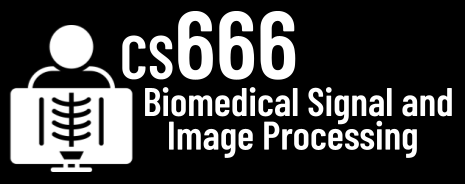
#Assignment 4

In [ ]:
# NAME: Luis González

In [ ]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [1]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
# we are using mahotas again, so lets install it!
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 17.9 MB/s eta 0:00:00


In [3]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [ ]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [4]:
!wget "https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1" -O xray.zip

--2026-04-12 22:17:57--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&e=1&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucebf7f6b49931e711e421ec4e89.dl.dropboxusercontent.com/cd/0/inline/C-fteaBBMfDbNSEJjckZ2ItPUQ4M50Guh5D407tdP7b53pj9fMdwN3Rl6kKXffVQE-UO3Q28blvGSXzS_UMOBUfITzl3f7ztAlVsWk62gRhDg3gvVaQO-R-PLVRYyJGmptg/file?dl=1# [following]
--2026-04-12 22:17:57--  https://ucebf7f6b49931e711e421ec4e89.dl.dropboxusercontent.com/cd/0/inline/C-fteaBBMfDbNSEJjckZ2ItPUQ4M50Guh5D407tdP7b53pj9fMdwN3Rl6kKXffVQE-UO3Q28blvGSXzS_UMOBUfITzl3f7ztAlVsWk62gRhDg3gvVaQO-R-PLVRYyJGmptg/file?dl=1
Resolving ucebf7f6b49931e711e421ec4e89.dl.dropboxusercontent.com (ucebf7f6b49931e711e421ec4e89.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:601d:15::a27d:50f
Connec

In [5]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [6]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

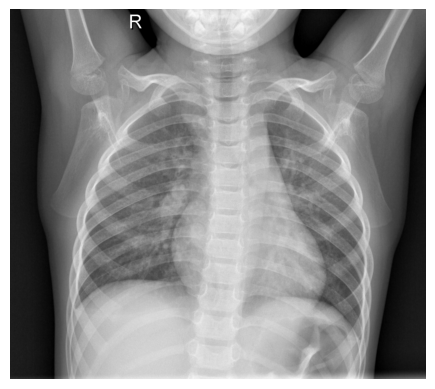

(1858, 2090)


In [8]:
# TODO: Please display this image and print the dimensions!
import matplotlib.pyplot as plt
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()
print(img.shape)

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [9]:
import numpy as np
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [ ]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) It checks if a picture is in color format and turns it into grayscale.
# TODO: Operation 2) It resizes every single picture to be exactly 300 by 300 pixels.
# TODO: Operation 3) It takes each individual picture and stacks it into one big group (an array) so the computer can read all of them at the exact same time.

In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

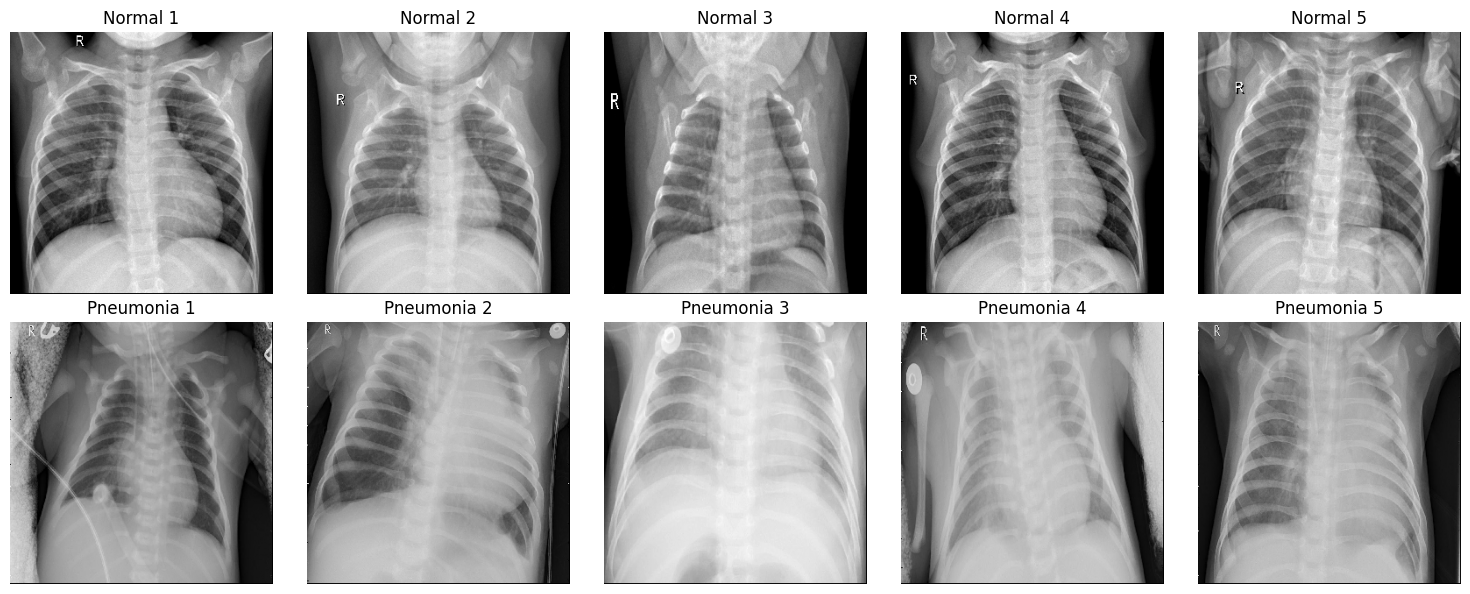

In [10]:
normal_images = data[0][:5]
pneumonia_images = data[1][:5]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))

for i in range(5):
    axes[0, i].imshow(normal_images[i], cmap='gray')
    axes[0, i].set_title(f"Normal {i+1}")
    axes[0, i].axis('off')

for i in range(5):
    axes[1, i].imshow(pneumonia_images[i], cmap='gray')
    axes[1, i].set_title(f"Pneumonia {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [ ]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [30]:
data[1].shape

(100, 300, 300)

In [11]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [12]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.repeat([0, 1, 2], TRAINING_COUNT)

In [13]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [14]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.repeat([0, 1, 2], TESTING_COUNT)

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [15]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [16]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [17]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [20]:
# TODO: In just a few sentences, please explain how the Random Forest works.

# Instead of relying on just one big decision tree to figure things out,
# a Random Forest builds a ton of smaller ones. It gives each tree a slightly different random piece of the data to look at.
# When it's time to make a guess, every single tree spits out its own answer. Then, they all just vote on it and whichever answer gets the most votes wins.

In [18]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.9083333333333333

In [ ]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [22]:
# Yes, a classification accuracy of 90.8% is very good!
# I'm surprised that with that tiny dataset we are able to achieve that performance using RF (and not CNNs for example).
# This tells us that the visual differences between the Normal, Pneumonia and Covid X-rays in the dataset are very distinct.
# For example, the pneumonia and covid lungs might be so much cloudier (meaning the raw pixel values are consistently brighter overall)
# that the Random Forest can easily figure out the difference just by looking at the raw pixel numbers, even without understanding the actual "picture"

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [ ]:
# TODO: The default number of trees is 100.

In [ ]:
# Now, please use a single tree and observe the testing performance.

In [23]:
single_tree_clf = RandomForestClassifier(n_estimators=1)
single_tree_clf.fit(X_train, y_train)
single_tree_clf.score(X_test, y_test)

0.7583333333333333

In [ ]:
# Are you surprised?

In [25]:
# Surprisingly, the accuracy still is 75% when using a single decision tree.
# I guess it can still recognize the obvious "cloudy" pixel patterns mentioned
# above and I assume there will be specific pixels that are very discriminative to make a classification (always bright when there is a disease).
# However, without the committee to average out mistakes, the single tree overfits to the training data and struggles to correctly
# classify the harder cases in the unseen testing set (obviously, there is a slight drop in performance).

**Bonus:** Let's take a closer look! [33 Points]

In [ ]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [31]:
X_covid_remaining = np.zeros((99, 300 * 300), dtype=np.float32)
covid_data = data[2]

for i, image in enumerate(covid_data[100 : 100 + 99]):
    image = image.ravel()
    image /= image.max()
    X_covid_remaining[i] = image

y_covid_remaining = np.repeat(2, 99)

clf.score(X_covid_remaining, y_covid_remaining)

0.898989898989899

In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

Total misclassified images: 10


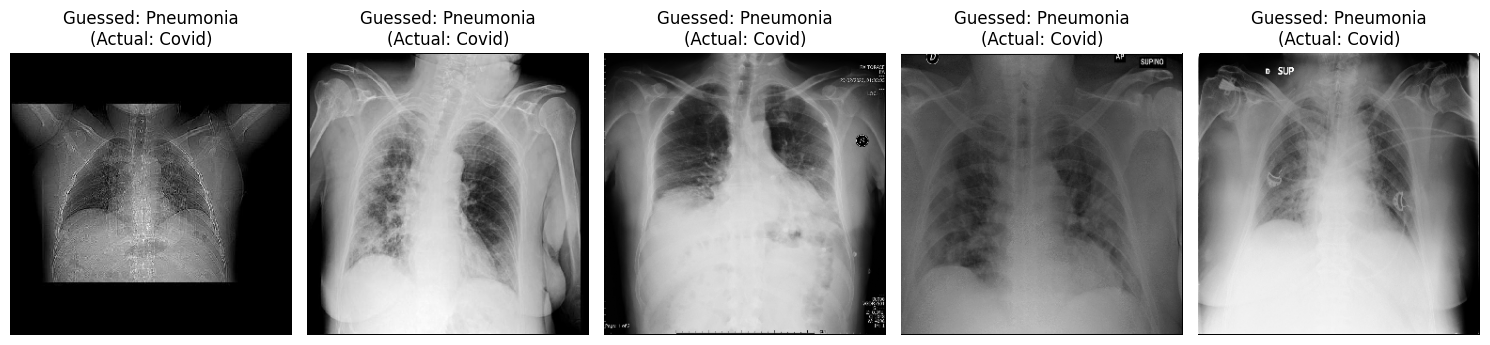

In [33]:
predictions = clf.predict(X_covid_remaining)

misclassified_indices = np.where(predictions != y_covid_remaining)[0]

print(f"Total misclassified images: {len(misclassified_indices)}")

num_to_show = np.min([len(misclassified_indices), 5])

fig, axes = plt.subplots(1, num_to_show, figsize=(15, 4))

if num_to_show == 1:
    axes = [axes]

for i in range(num_to_show):
    original_index = misclassified_indices[i]

    image_2d = X_covid_remaining[original_index].reshape(300, 300)

    wrong_guess = predictions[original_index]
    label_map = {0: "Normal", 1: "Pneumonia"}
    predicted_text = label_map.get(wrong_guess, "Unknown")

    axes[i].imshow(image_2d, cmap='gray')
    axes[i].set_title(f"Guessed: {predicted_text}\n(Actual: Covid)")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# The reason the model guessed Pneumonia for the Covid images is mainly that both sicknesses cause fluid in the lungs, which shows up as bright, cloudy patches.
# Because we flattened the pictures into a single line of pixels, the Random Forest lost all sense of 2D shapes and just learned a basic math rule:
# "lots of bright white pixels = Pneumonia."

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw